# **Idemia Datachallenge (IADATA704): Face Occlusion Prediction**

---

In [14]:
# --- Standard Library Imports ---
import os

# --- Third-Party Library Imports ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import random
import torch
from torch.utils.data import WeightedRandomSampler
import torchvision.transforms as T

# -----------------------------------------------------------------
# /!\ This notebook MUST BE at the root of the project folder /!\
# -----------------------------------------------------------------

# --- Local Project Modules ---
from src import config

# --- Check files existence ---
files = [config.DF_TRAIN,
         config.DF_TEST,
         config.IMAGE_TEST]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/occlusion_datasets/train.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/occlusion_datasets/test_students.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database1/img00000048.webp


## **1. Dataset overview**

In [15]:
df_train = pd.read_csv(config.DF_TRAIN, delimiter=',')
df_train = df_train.dropna()

df_test = pd.read_csv(config.DF_TEST, delimiter=',')
df_test = df_test.dropna()

In [16]:
# --- Train database ---
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   filename       100000 non-null  str    
 1   FaceOcclusion  100000 non-null  float64
 2   gender         100000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 2.3 MB


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [17]:
# --- Test database ---
df_test.info()
df_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  29980 non-null  str  
dtypes: str(1)
memory usage: 234.3 KB


,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


## **2. Occlusion distribution**

Occlusion stats
min_val =	0.00
max_val =	1.00
mean_val =	0.08
median_val =	0.05


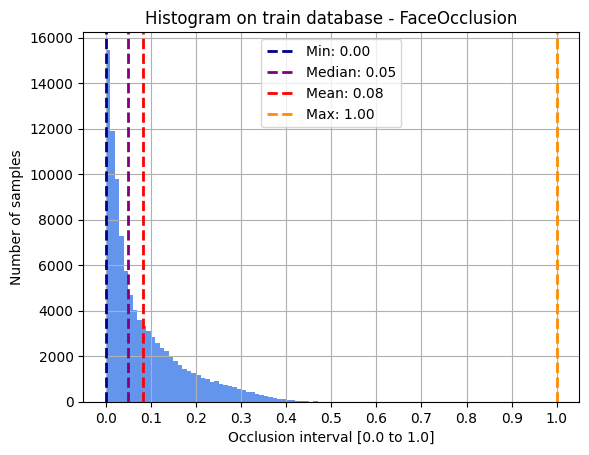

In [18]:
# --- Occlusion stats ---
min_val = df_train['FaceOcclusion'].min()
max_val = df_train['FaceOcclusion'].max()
mean_val = df_train['FaceOcclusion'].mean()
median_val = df_train['FaceOcclusion'].median()

print("====================")
print("Occlusion stats")
print("====================")
print(f"min_val =\t{min_val:.2f}")
print(f"max_val =\t{max_val:.2f}")
print(f"mean_val =\t{mean_val:.2f}")
print(f"median_val =\t{median_val:.2f}")
print("====================")

# --- Histogram ---
hist_occlusion = df_train.hist(column = ['FaceOcclusion'], bins = 100, color='cornflowerblue')

ax = hist_occlusion[0,0]
ax.set_title(f"Histogram on train database - FaceOcclusion")

# Add vertical lines for each stat
ax.axvline(min_val, color='#00008B', linestyle='dashed', linewidth=2, label=f'Min: {min_val:.2f}')
ax.axvline(median_val, color= '#800080', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')
ax.axvline(mean_val, color='#FF0000', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
ax.axvline(max_val, color='#FF8C00', linestyle='dashed', linewidth=2, label=f'Max: {max_val:.2f}')

# Set horizontal axis units
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_ylabel("Number of samples")
ax.set_xlabel("Occlusion interval [0.0 to 1.0]")
ax.legend()
plt.show()

In [19]:
# --- Counts by occlusion interval ---

# Custom interval: from 0.0 to 1.0 with a step of 0.1
bin_edges = np.arange(0.0, 1.1, 0.1)
bin_labels = [f"[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}]" for i in range(len(bin_edges)-1)]

# --- Calculate bin frequencies using pd.cut ---
df_train['occlusion_bin'] = pd.cut(df_train['FaceOcclusion'], 
                                   bins=bin_edges, 
                                   labels=bin_labels, 
                                   include_lowest=True  # Ensures 0.0 is captured in the first bin
                                   )
# Count occurrences per interval
bin_counts = df_train['occlusion_bin'].value_counts().sort_index()

# --- Print beautifully formatted breakdown ---
print("================================================")
print("Image count per ccclusion interval")
print("================================================")
for interval, count in bin_counts.items():
    percentage = (count / len(df_train)) * 100
    print(f"Interval {interval:<14} : {count:>6} images ({percentage:>5.2f}%)")
print("================================================")

Image count per ccclusion interval
Interval [0.00, 0.10]   :  68929 images (68.93%)
Interval [0.10, 0.20]   :  19558 images (19.56%)
Interval [0.20, 0.30]   :   8372 images ( 8.37%)
Interval [0.30, 0.40]   :   2865 images ( 2.86%)
Interval [0.40, 0.50]   :    240 images ( 0.24%)
Interval [0.50, 0.60]   :     26 images ( 0.03%)
Interval [0.60, 0.70]   :      5 images ( 0.01%)
Interval [0.70, 0.80]   :      2 images ( 0.00%)
Interval [0.80, 0.90]   :      0 images ( 0.00%)
Interval [0.90, 1.00]   :      3 images ( 0.00%)


## **3. Gender distribution**

% per gender
67600 are men, i.e. 67.60%
32400 are women, i.e. 32.40%


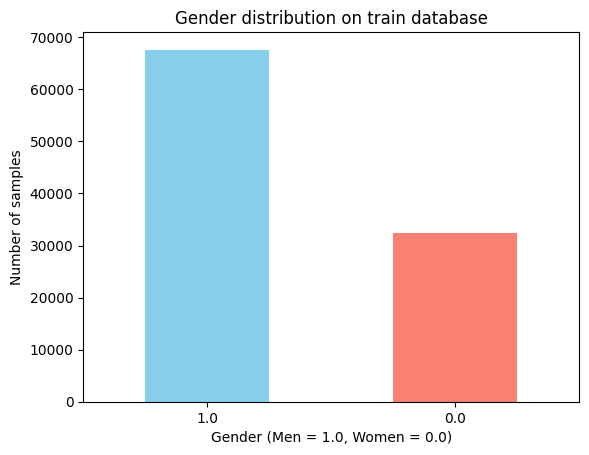

In [20]:
# --- Gender metrics ---
gender_counts = df_train['gender'].value_counts()
#print(gender_counts)
total = gender_counts.sum()

print("==================")
print("% per gender")
print("==================")
print(f"{gender_counts[1]} are men, i.e. {(gender_counts[1]/total)*100:.2f}%")
print(f"{gender_counts[0]} are women, i.e. {(gender_counts[0]/total)*100:.2f}%")
print("==================")

# --- Barplot ---
gender_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Gender distribution on train database")
plt.xlabel("Gender (Men = 1.0, Women = 0.0)")
plt.ylabel("Number of samples")
plt.xticks(rotation=0) # Pour garder les labels horizontaux
plt.show()

## **4. Images display**

### **4.1 Train database exploration**

Here we aim to display random images on three occlusion invertals:

- Interval 1 $[0.0, 0.2]$
- interval 2 $(0.2, 0.4]$
- interval 3 $(0.4, 0.5]$
- Interval 4 $(0.5, 1.0]$

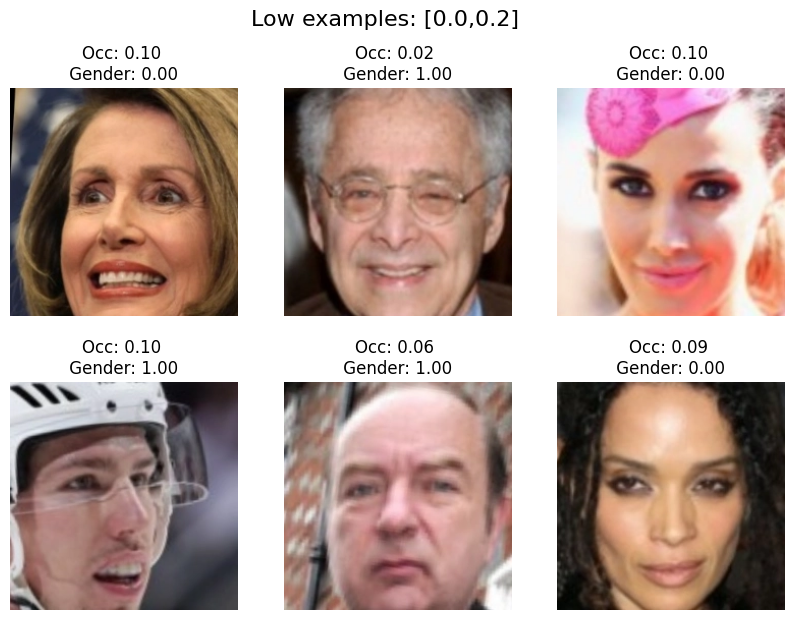

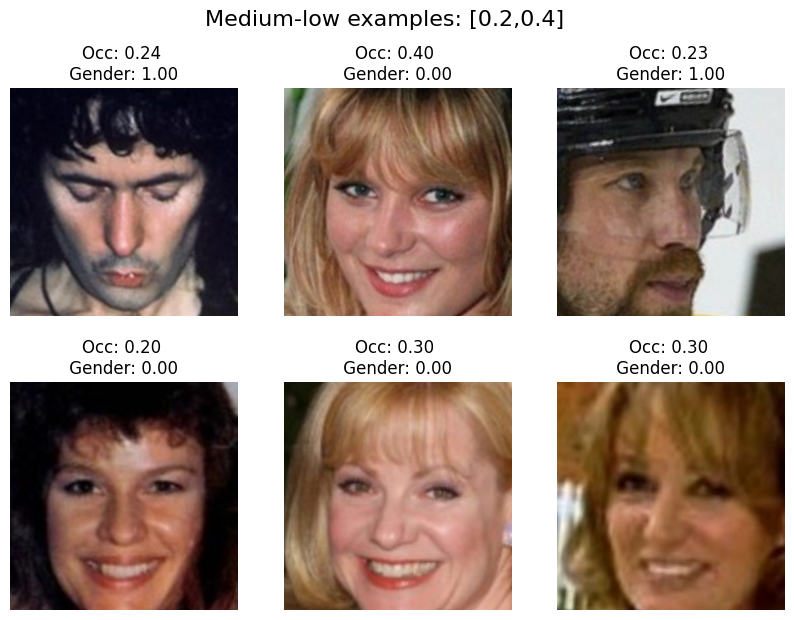

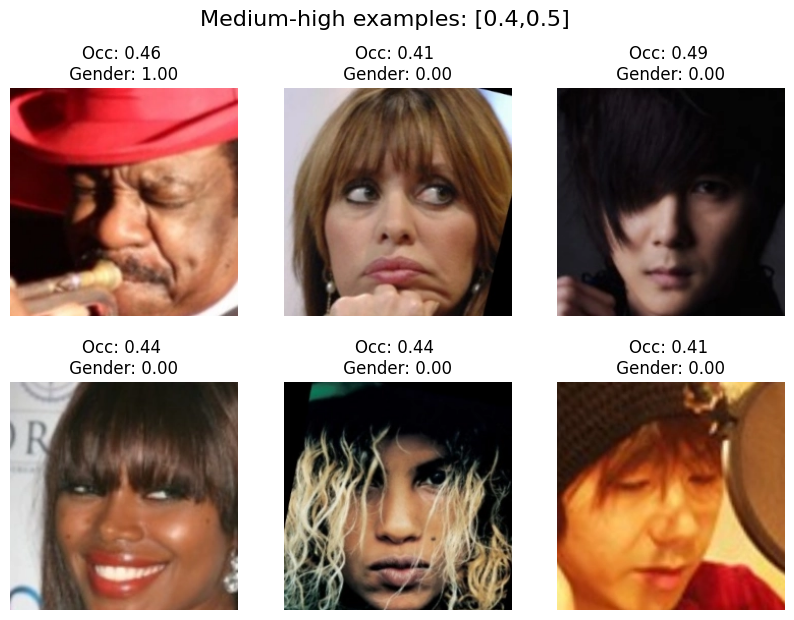

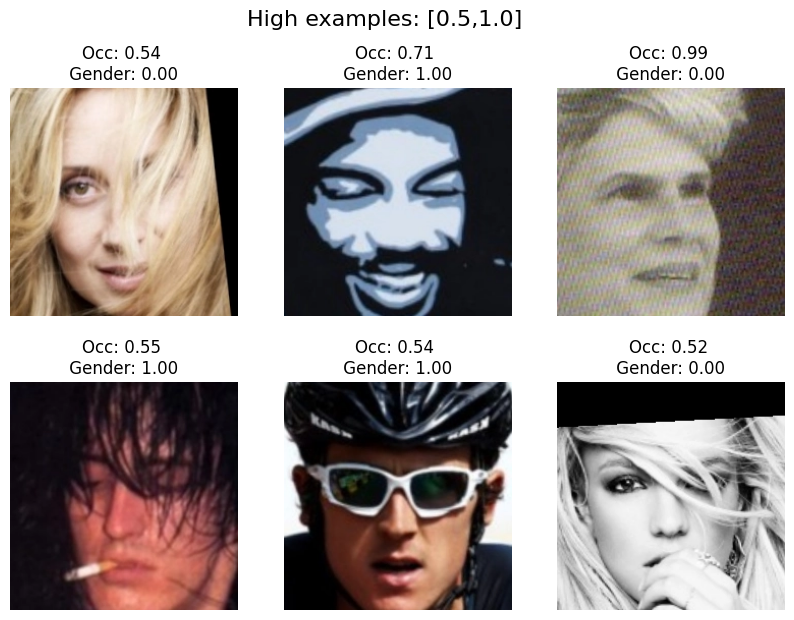

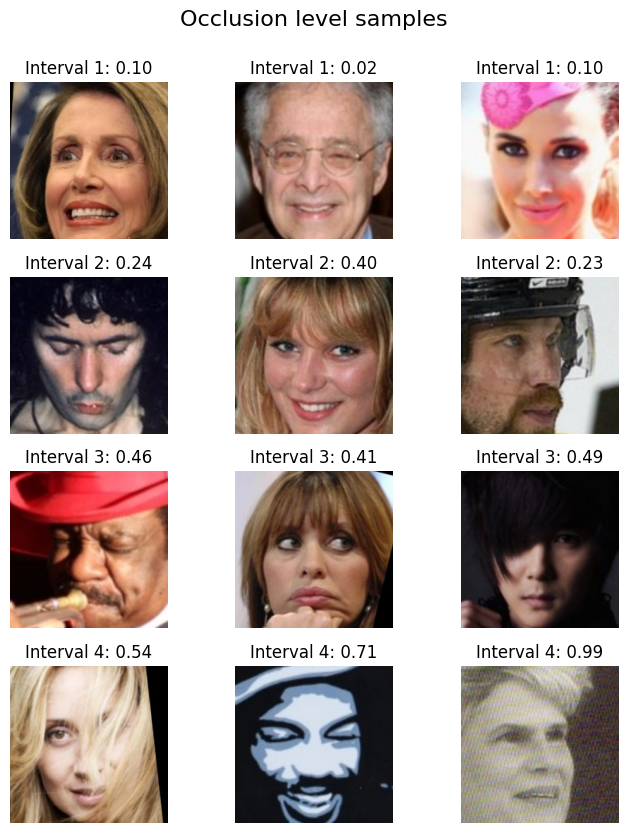

In [21]:
def display_mosaic_train(df, interval, title):
    
    # Apply interval
    if interval[0] == 0.0:
        df_subset = df[(df['FaceOcclusion'] >= interval[0]) & (df['FaceOcclusion'] <= interval[1])]
    else:
        df_subset = df[(df['FaceOcclusion'] > interval[0]) & (df['FaceOcclusion'] <= interval[1])]

    # Perform random sampling
    samples = df_subset.sample(n=min(6, len(df_subset)), random_state = 42)

    # Build figure
    fig, axes = plt.subplots(2,3, figsize = (10,7))
    axes = axes.flatten()   # Takes 2D matrix and collapses it into a 1D array
    fig.suptitle(f"{title} examples: [{interval[0]},{interval[1]}]", fontsize=16)

    # List of files
    files = []
    occlusions = []
    genders = []

    # samples.iterrows() => Returns each row of the dataframe
    # idx => Row label / index
    # row => Row content
    for i, (idx, row) in enumerate(samples.iterrows()):

        # Retrieve row data
        occlusion = row['FaceOcclusion']
        gender = row['gender']
        occlusions.append(occlusion)
        genders.append(gender)
        
        # Load image
        filename = row['filename']
        FILE_DIR = f"/{config.IMAGE_DIR}/{filename}"
        files.append(FILE_DIR)
        img2display = Image.open(FILE_DIR)

        # Assign image to the subplot
        axes[i].imshow(img2display)
        axes[i].set_title(f"Occ: {occlusion:.2f} \n Gender: {gender:.2f} ")        
        axes[i].axis('off') # Hide axes

        ax.imshow(img2display)

    return files, occlusions, genders

def display_mosaic_3x3_train(df, files_1, files_2, files_3, files_4):
    
    files = files_1[:3] + files_2[:3] + files_3[:3] + files_4[:3]

    #for file in files:
    #    print(file)
    
    
    # Organize lists into a structure for easier looping
    #rows_data = [files_1, files_med, files_high]
    #row_labels = ["Interval 1", "Interval 2", "Interval 3", "Interval 4"]
 
    # Create a 3x3 grid
    fig, axes = plt.subplots(4, 3, figsize=(7, 9))
    axes = axes.flatten()
    fig.suptitle("Occlusion level samples", fontsize=16, y=0.95)
    
    
    for i, file_path in enumerate(files):
        #print(i)
        #print(file)

        # Load image
        #FILE_DIR = f"/{config.IMAGE_DIR}/{filen_path}"
        #files.append(FILE_DIR)
        img2display = Image.open(file_path)

        # Recover row from DF
        row = df[df['filename'].apply(lambda x: x in file_path)].iloc[0]

        # Retrieve row data
        filename = row['filename']
        occlusion = row['FaceOcclusion']
        gender = row['gender']

        if i < 3:
            # Assign image to the subplot
            axes[i].imshow(img2display)
            axes[i].set_title(f"Interval 1: {occlusion:.2f}")
            axes[i].axis('off') # Hide axes
        elif i < 6:
            # Assign image to the subplot
            axes[i].imshow(img2display)
            axes[i].set_title(f"Interval 2: {occlusion:.2f}")
            axes[i].axis('off') # Hide axes
        elif i < 9:
            # Assign image to the subplot
            axes[i].imshow(img2display)
            axes[i].set_title(f"Interval 3: {occlusion:.2f}")
            axes[i].axis('off') # Hide axes
        elif i < 12:
            # Assign image to the subplot
            axes[i].imshow(img2display)
            axes[i].set_title(f"Interval 4: {occlusion:.2f}")
            axes[i].axis('off') # Hide axes

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# These intervalles were guided based on the test database histogram for FaceOcclusion
files_low,      occs_low,        genders_low         = display_mosaic_train(df_train, [0.0, 0.2], "Low")
files_med_low,  occs_med_low,    genders_med_low     = display_mosaic_train(df_train, [0.2,0.4], "Medium-low")
files_med_hi,   occs_med_hi,     genders_med_hi      = display_mosaic_train(df_train, [0.4,0.5], "Medium-high")
files_hi,       occs_med,        genders_med_hi      = display_mosaic_train(df_train, [0.5,1.0], "High")

display_mosaic_3x3_train(df_train, files_low, files_med_low, files_med_hi, files_hi)

### **4.2 Test database exploration**

['/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01wqmm8/8-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01l5d3g/35-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01s3fm/61-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01qlryl/28-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01p3nw_/46-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01pdbs/23-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.01bdny/59-FaceId-0_align.webp',
 '/home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3

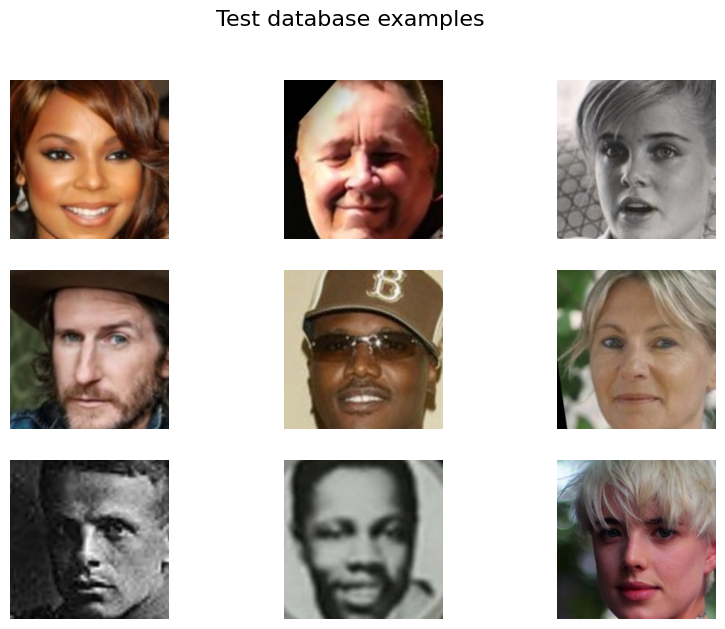

In [22]:
def display_mosaic_test(df, title):
    
    # Apply interval
    #df_subset = df[(df['FaceOcclusion'] >= interval[0]) & (df['FaceOcclusion'] <= interval[1])]

    # Perform random sampling
    samples = df.sample(n=min(9, len(df)), random_state = 80)

    # Build figure
    fig, axes = plt.subplots(3,3, figsize = (10,7))
    axes = axes.flatten()   # Takes 2D matrix and collapses it into a 1D array
    fig.suptitle(f"{title} examples", fontsize=16)

    # List of files
    files = []

    # samples.iterrows() => Returns each row of the dataframe
    # idx => Row label / index
    # row => Row content
    for i, (idx, row) in enumerate(samples.iterrows()):

        # Retrieve row data
        filename = row['filename']
        #occlusion = row['FaceOcclusion']
        #gender = row['gender']
        
        # Load image
        FILE_DIR = f"/{config.IMAGE_DIR}/{filename}"
        files.append(FILE_DIR)
        img2display = Image.open(FILE_DIR)

        # Assign image to the subplot
        axes[i].imshow(img2display)
        #axes[i].set_title(f"Occ: {occlusion:.2f} \n Gender: {gender:.2f} ")        
        axes[i].axis('off') # Hide axes

        ax.imshow(img2display)

    return files

display_mosaic_test(df_test, "Test database")

## **5. Weighted sampling tests**

In [23]:
female_count = len(df_train[df_train['gender'] == 0.0])
male_count = len(df_train[df_train['gender'] == 1.0])
print(f"-> Females: {female_count}, Males: {male_count}")

# 2. Calculate inverse class weights
class_weights = {
    0.0: 1.0 / female_count,
    1.0: 1.0 / male_count
}

# 5 samples dataframe
df_train_small = df_train.iloc[:7]

# 3. Create weight list for the entire dataset
sample_weights = [class_weights[g] for g in df_train_small['gender']]

print(sample_weights)

sample_weights_tensor = torch.DoubleTensor(sample_weights)

params_train = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 4}

df_train_small.head(7)

-> Females: 32400, Males: 67600
[1.4792899408284024e-05, 1.4792899408284024e-05, 3.08641975308642e-05, 1.4792899408284024e-05, 1.4792899408284024e-05, 1.4792899408284024e-05, 1.4792899408284024e-05]


,filename,FaceOcclusion,gender,occlusion_bin
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0,"[0.00, 0.10]"
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0,"[0.00, 0.10]"
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0,"[0.00, 0.10]"
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0,"[0.20, 0.30]"
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0,"[0.20, 0.30]"
5,database3/database3/m.0260ghm/60-FaceId-0_alig...,0.017832,1.0,"[0.00, 0.10]"
6,database3/database3/m.02607_t/115-FaceId-0_ali...,0.008408,1.0,"[0.00, 0.10]"


## **6. Data autmentation tests**

Loaded image: /home/mambo/Documents/data-challenge-idemia/data/crops/Crop_224_5fp_100K/database3/database3/m.016wdq/47-FaceId-0_align.webp
Image dimensions: 224x224 pixels (Total area: 50176 px)
Original occlusion value: 0.0219
Bounding box coordinates: Top-Left(2, 49) to Bottom-Right(202, 126)
Box dimensions: 200x77 px
Mask covers exactly: 15400 px
Calculated Area Ratio: 0.3069 (+30.7%)
Updated Dynamic Ground Truth: 0.3289


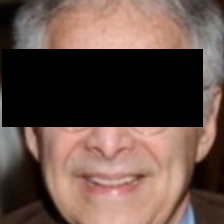

In [24]:
# --- Load single image from low occlusion interval ---
sample_img = files_low[1]
original_occlusion = occs_low[1]
img = Image.open(sample_img).convert('RGB')
# Dimensions
w, h = img.size

print("=" * 142)
print(f"Loaded image: {sample_img}")
print(f"Image dimensions: {w}x{h} pixels (Total area: {w*h} px)")
print(f"Original occlusion value: {original_occlusion:.4f}")
print("=" * 142)


# --- Build bounding box ---
w_up_lim = 1.0
w_bottom_lim = 0.4
w_ratio = random.random() * (w_up_lim - w_bottom_lim) + w_bottom_lim

h_up_lim = 0.4
h_bottom_lim = 0.2
h_ratio = random.random() * (h_up_lim - h_bottom_lim) + h_bottom_lim

box_w = int(w * w_ratio)
box_h = int(w * h_ratio)

# Random position
x1 = random.randint(0, w - box_w)
y1 = random.randint(0, h - box_h)

print(f"Bounding box coordinates: Top-Left({x1}, {y1}) to Bottom-Right({x1 + box_w}, {y1 + box_h})")
print(f"Box dimensions: {box_w}x{box_h} px")

# --- Compute new occlusion value ---
mask_area = box_w * box_h
total_area = w * h
area_ratio = mask_area / total_area
new_occlusion = min(1.0, original_occlusion + area_ratio)   # Occlusion value cannot exeed 1.0

print(f"Mask covers exactly: {mask_area} px")
print(f"Calculated Area Ratio: {area_ratio:.4f} (+{area_ratio*100:.1f}%)")
print(f"Updated Dynamic Ground Truth: {new_occlusion:.4f}")

# --- Apply the augmentation ---
draw = ImageDraw.Draw(img)
draw.rectangle([x1, y1, x1 + box_w, y1 + box_h], fill="black")

img

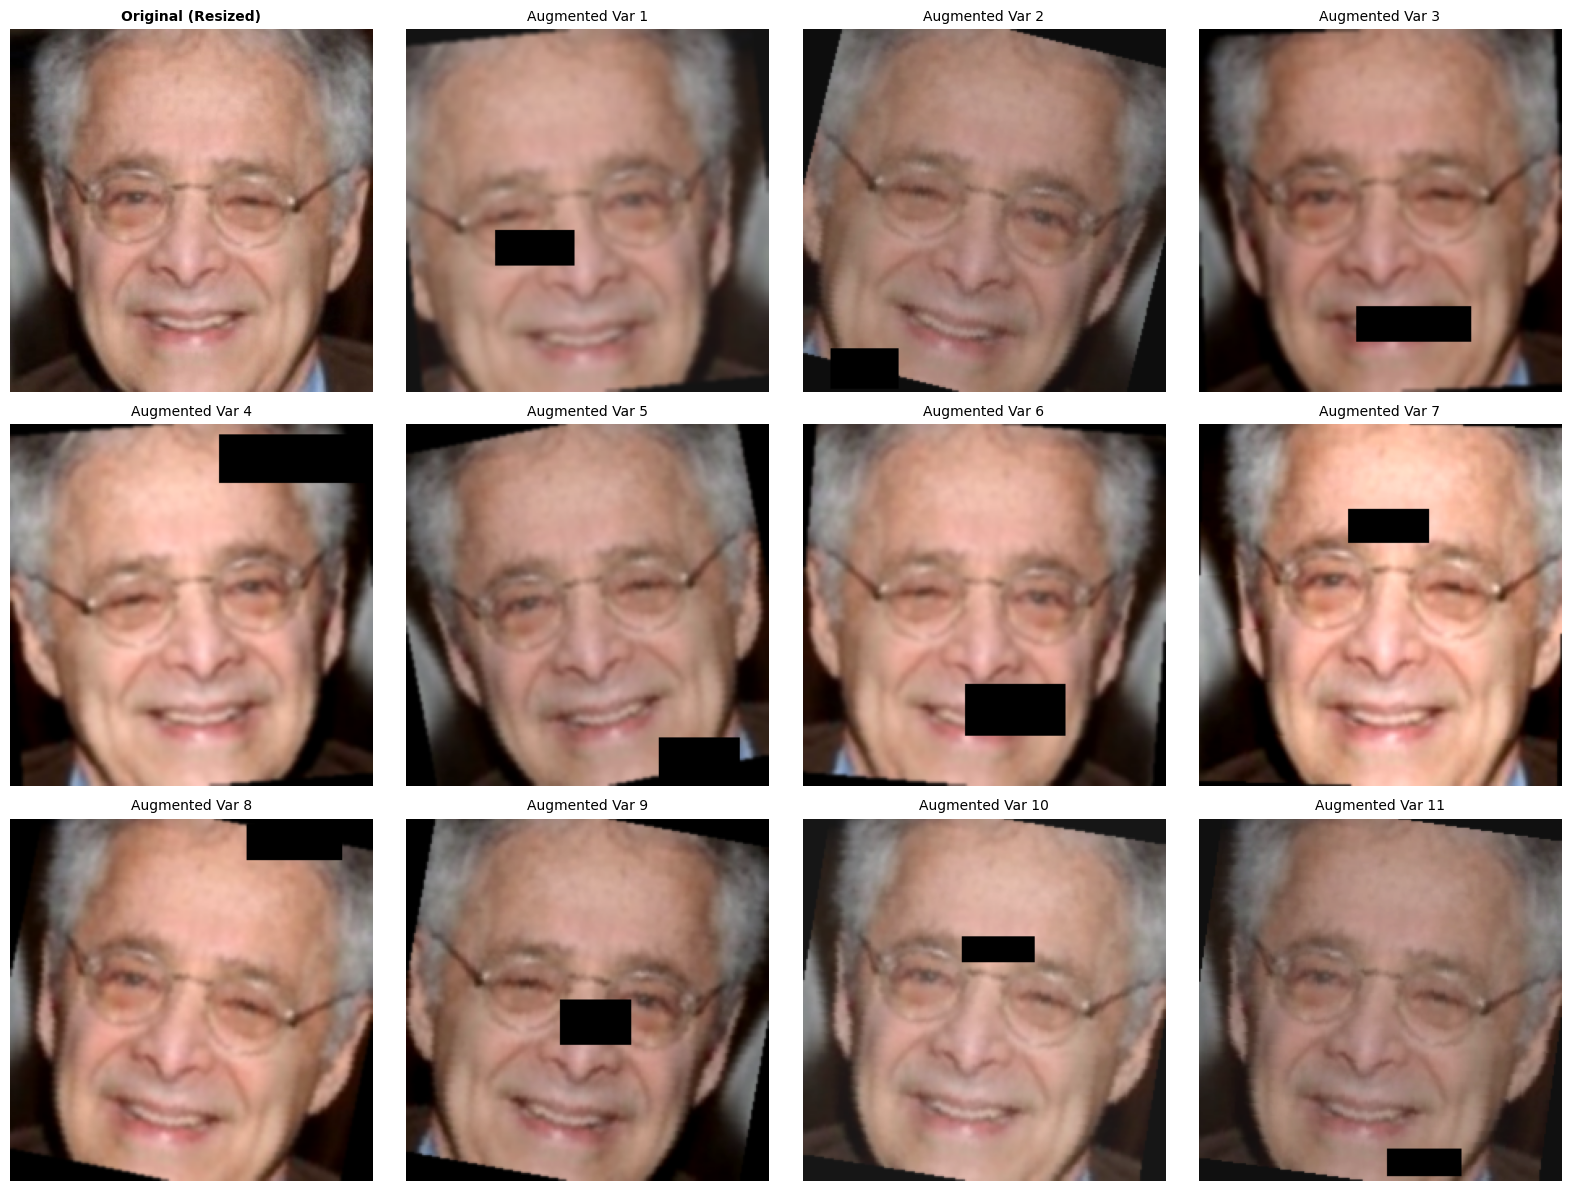

In [ ]:
# --- Load single image from low occlusion interval ---
sample_img = files_low[1]
original_occlusion = occs_low[1]
img = Image.open(sample_img).convert('RGB')

# --- Data augmentation pipeline ---
test_transforms = T.Compose([
    T.Resize((224, 224)), 
    
    # Apply Blur
    T.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)),
    
    # Convert to Tensor (Required for Random Erasing)
    T.ToTensor(),
    
    # Force the erase to happen (p=1.0) to see what it looks like    
    # scale => The Total Area (Size)
    # ratio => The Aspect Ratio (Shape) = Height / Width
    T.RandomErasing(p=1.0, scale=(0.08, 0.15), ratio=(0.25, 0.7), value=0),
    
    # Convert back to PIL Image so Matplotlib can easily display it
    T.ToPILImage()
])

# --- 1. Tes paramètres optimisés ---
SCALE = [0.01, 0.06]       # Carrés noirs minuscules (max 6% de l'image)
RATIO = [0.3, 0.7]         # Rectangles horizontaux (type lunettes/frange)
TRANSFORM_PROB = 0.25

# --- 2. Pipeline spécial VISUALISATION (Pas de Normalisation, p=1.0 pour TOUT voir) ---
# On force p=1.0 sur le RandomErasing pour être SÛR de voir l'effet du rectangle noir sur tes tests
test_visual_transforms = T.Compose([
    T.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0),
    T.RandomHorizontalFlip(p=0.5),
    T.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 1.5)),
    T.ToTensor(),        
    T.RandomErasing(p=1.0, scale=(SCALE[0], SCALE[1]), ratio=(RATIO[0], RATIO[1]), value=0),
    T.ToPILImage()
])

# --- Plot Original vs. Augmented ---
fig, axes = plt.subplots(3, 4, figsize=(16, 12)) 
axes = axes.flatten()

axes[0].imshow(img.resize((224, 224)))
axes[0].set_title("Original (Resized)", fontsize=10, fontweight='bold')
axes[0].axis('off')

for i in range(1, 12):
    aug_img = test_visual_transforms(img)  # Utilise le pipeline visuel
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented Var {i}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()